# Preparação dos Dados — Campeonato Brasileiro

Este notebook carrega, limpa e divide os dados históricos do Brasileirão (2003–2025) em dois arquivos parquet para consumo pelos notebooks de modelagem (Fases 2–4).

## 1. Configuração e importações

In [1]:
import os

# Configuração para renderização headless (sem display gráfico)
# Deve ser feita ANTES de qualquer importação de matplotlib/seaborn
os.environ['MPLBACKEND'] = 'agg'
os.environ['MPLCONFIGDIR'] = '/tmp/matplotlib-config'

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow

print(f"pandas {pd.__version__}")
print(f"pyarrow {pyarrow.__version__}")
print(f"seaborn {sns.__version__}")

pandas 2.3.3
pyarrow 24.0.0
seaborn 0.13.2


## 2. Carregamento do CSV

In [2]:
df = pd.read_csv('dados/archive/campeonato-brasileiro-full.csv')

assert len(df) == 9165, f"Esperado 9165 linhas, obtido {len(df)}"
assert list(df.columns) == [
    'ID', 'rodata', 'data', 'hora', 'mandante', 'visitante',
    'formacao_mandante', 'formacao_visitante', 'tecnico_mandante',
    'tecnico_visitante', 'vencedor', 'arena', 'mandante_Placar',
    'visitante_Placar', 'mandante_Estado', 'visitante_Estado', 'arrecadacao'
], f"Colunas inesperadas: {list(df.columns)}"

print(f"shape: {df.shape}")
print(df.dtypes)

shape: (9165, 17)
ID                      int64
rodata                  int64
data                   object
hora                   object
mandante               object
visitante              object
formacao_mandante      object
formacao_visitante     object
tecnico_mandante       object
tecnico_visitante      object
vencedor               object
arena                  object
mandante_Placar         int64
visitante_Placar        int64
mandante_Estado        object
visitante_Estado       object
arrecadacao           float64
dtype: object


## 3. Parse da coluna de data e verificação de ordem cronológica

In [3]:
df['date'] = pd.to_datetime(df['data'], format='%d/%m/%Y')

assert df['date'].is_monotonic_increasing, "CSV não está ordenado por data — ordenação necessária"
assert df['date'].isnull().sum() == 0, "Valores nulos encontrados na coluna 'date'"

print(f"Data mínima: {df['date'].min()}")
print(f"Data máxima: {df['date'].max()}")

Data mínima: 2003-03-29 00:00:00
Data máxima: 2025-12-07 00:00:00


## 4. Derivação da coluna alvo `result`

In [4]:
def derive_result(row):
    if row['vencedor'] == '-':
        return 'Draw'
    elif row['vencedor'] == row['mandante']:
        return 'HomeWin'
    else:
        return 'AwayWin'

df['result'] = df.apply(derive_result, axis=1)

assert df['result'].isnull().sum() == 0, "Valores nulos em 'result'"
assert set(df['result'].unique()) == {'HomeWin', 'Draw', 'AwayWin'}, f"Valores inesperados: {set(df['result'].unique())}"

print(df['result'].value_counts())

result
HomeWin    4550
Draw       2421
AwayWin    2194
Name: count, dtype: int64


## 5. Renomeação de colunas, remoção das não utilizadas e adição de `season`

In [5]:
df = df.rename(columns={
    'mandante':        'home_team',
    'visitante':       'away_team',
    'mandante_Placar': 'home_score',
    'visitante_Placar':'away_score',
    'rodata':          'round',
    'mandante_Estado': 'home_state',
    'visitante_Estado':'away_state',
    'ID':              'id',
})

# season = ano do calendário. Exceção conhecida: o Brasileirão 2020 foi suspenso
# por COVID e terminou em fev/2021 — ~185 partidas (rodadas 28-38) ficam com
# season=2021 por date.dt.year. Isso é aceitável: a coluna é auxiliar para features
# de Fase 2 e heurísticas de mês quebram para 2003-2005 (campeonatos com 24+ times
# que cruzavam o ano-calendário).
df['season'] = df['date'].dt.year

# Selecionar apenas as colunas necessárias — colunas com muitos nulos
# (formacao_*, tecnico_*, arena, arrecadacao) são excluídas por seleção de colunas,
# NÃO por df.dropna(), que removeria ~96% das linhas
keep_cols = ['id', 'date', 'season', 'round', 'home_team', 'away_team',
             'home_score', 'away_score', 'home_state', 'away_state', 'result']
df = df[keep_cols]

assert df.isnull().sum().sum() == 0, f"Valores nulos encontrados após seleção: {df.isnull().sum()}"
assert list(df.columns) == keep_cols, f"Colunas inesperadas: {list(df.columns)}"

print(f"shape: {df.shape}")
print(df.head(2))

shape: (9165, 11)
   id       date  season  round     home_team away_team  home_score  \
0   1 2003-03-29    2003      1       Guarani     Vasco           4   
1   2 2003-03-29    2003      1  Athletico-PR    Gremio           2   

   away_score home_state away_state   result  
0           2         SP         RJ  HomeWin  
1           0         PR         RS  HomeWin  


## 6. Normalização dos nomes dos times e verificação dos 10 clubes principais

In [6]:
# Nomes no CSV já são consistentes (46 nomes únicos, 0 conflitos).
# O dicionário é uma guarda defensiva — popule-o quando variantes aparecerem
# (ex.: 'Atletico MG': 'Atletico-MG' — não presente atualmente)
canonical_names = {}

for col in ['home_team', 'away_team']:
    df[col] = df[col].replace(canonical_names)

team_counts = pd.concat([df['home_team'], df['away_team']]).value_counts()

top_clubs = [
    'Flamengo', 'Corinthians', 'Sao Paulo', 'Fluminense', 'Santos',
    'Internacional', 'Atletico-MG', 'Athletico-PR', 'Gremio', 'Palmeiras'
]

for club in top_clubs:
    assert team_counts.get(club, 0) >= 380, f"{club}: {team_counts.get(club, 0)} < 380"

print(team_counts.head(15))

Flamengo         894
Fluminense       894
Sao Paulo        894
Santos           856
Internacional    856
Corinthians      856
Atletico-MG      855
Athletico-PR     818
Gremio           814
Palmeiras        810
Cruzeiro         780
Botafogo-RJ      772
Vasco            704
Goias            590
Coritiba         590
Name: count, dtype: int64


## 7. Divisão temporal treino/teste

In [7]:
train_df = df[df['date'].dt.year <= 2022].copy()
test_df  = df[df['date'].dt.year >= 2023].copy()

assert len(train_df) == 8025, f"Esperado 8025 linhas de treino, obtido {len(train_df)}"
assert len(test_df)  == 1140, f"Esperado 1140 linhas de teste, obtido {len(test_df)}"
assert len(train_df) + len(test_df) == 9165, "Soma treino+teste difere do total"
assert len(set(train_df.index) & set(test_df.index)) == 0, "Sobreposição de índices entre treino e teste!"
assert train_df['date'].max() < test_df['date'].min(), "Sobreposição temporal entre treino e teste!"

print(f"Treino: {len(train_df)} linhas ({train_df['date'].dt.year.min()}–{train_df['date'].dt.year.max()})")
print(f"Teste:  {len(test_df)} linhas ({test_df['date'].dt.year.min()}–{test_df['date'].dt.year.max()})")

Treino: 8025 linhas (2003–2022)
Teste:  1140 linhas (2023–2025)


## 8. Salvamento dos arquivos parquet

In [8]:
os.makedirs('dados', exist_ok=True)

train_df.to_parquet('dados/matches_train.parquet', engine='pyarrow', index=False)
test_df.to_parquet('dados/matches_test.parquet',   engine='pyarrow', index=False)

assert os.path.exists('dados/matches_train.parquet'), "matches_train.parquet não encontrado!"
assert os.path.exists('dados/matches_test.parquet'),  "matches_test.parquet não encontrado!"

# Leitura de verificação (round-trip)
expected_cols = ['id', 'date', 'season', 'round', 'home_team', 'away_team',
                 'home_score', 'away_score', 'home_state', 'away_state', 'result']

reload_train = pd.read_parquet('dados/matches_train.parquet')
assert len(reload_train) == 8025, f"Round-trip train: esperado 8025, obtido {len(reload_train)}"
assert list(reload_train.columns) == expected_cols, f"Colunas inesperadas no train parquet: {list(reload_train.columns)}"

reload_test = pd.read_parquet('dados/matches_test.parquet')
assert len(reload_test) == 1140, f"Round-trip test: esperado 1140, obtido {len(reload_test)}"
assert list(reload_test.columns) == expected_cols, (
    f"Colunas inesperadas no test parquet: {list(reload_test.columns)}"
)

print(f"Salvo: treino={len(train_df)} linhas, teste={len(test_df)} linhas")


Salvo: treino=8025 linhas, teste=1140 linhas


## 9. Análise exploratória: distribuição das classes

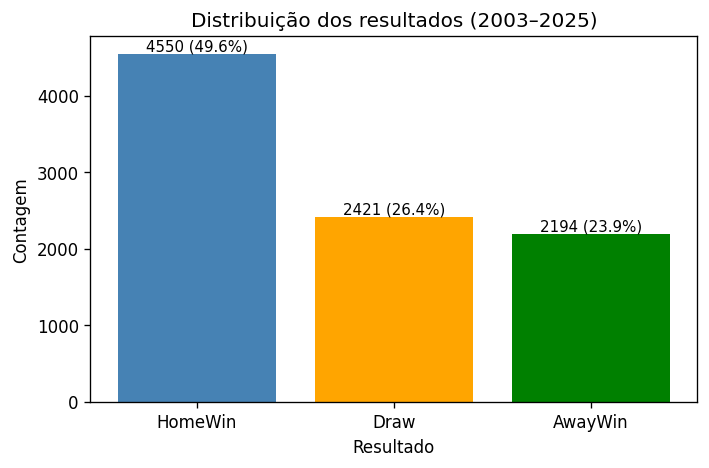

Distribuição dos resultados (contagem):
result
HomeWin    4550
Draw       2421
AwayWin    2194
Name: count, dtype: int64

Distribuição dos resultados (proporção):
result
HomeWin    0.496454
Draw       0.264157
AwayWin    0.239389
Name: proportion, dtype: float64

Acurácia baseline 'sempre casa': 49.6%


In [9]:
# Nota: a taxa de vitória em casa neste dataset é 49.6%, NÃO ~46%.
# O valor ~46% em CLAUDE.md/STATE.md é incorreto — o dataset real mostra 49.6%.
# Os notebooks de Fase 3 devem usar 49.6% como baseline 'sempre casa'.

from io import BytesIO
from IPython.display import Image, display
from matplotlib.backends.backend_agg import FigureCanvasAgg
from matplotlib.figure import Figure

# Usar pd.concat para garantir que temos o dataframe completo
df_full = pd.concat([train_df, test_df])

order = ['HomeWin', 'Draw', 'AwayWin']
fig = Figure(figsize=(6, 4))
FigureCanvasAgg(fig)
ax = fig.subplots()

counts = [df_full[df_full['result'] == r].shape[0] for r in order]
bars = ax.bar(order, counts, color=['steelblue', 'orange', 'green'])
ax.set_title('Distribuição dos resultados (2003–2025)')
ax.set_xlabel('Resultado')
ax.set_ylabel('Contagem')

for bar, count in zip(bars, counts):
    ax.annotate(
        f'{count} ({count/len(df_full)*100:.1f}%)',
        (bar.get_x() + bar.get_width() / 2., bar.get_height()),
        ha='center', va='bottom', fontsize=9
    )

fig.tight_layout()
buffer = BytesIO()
fig.savefig(buffer, format='png', bbox_inches='tight', dpi=120)
display(Image(data=buffer.getvalue()))

print("Distribuição dos resultados (contagem):")
print(df_full['result'].value_counts())
print()
print("Distribuição dos resultados (proporção):")
print(df_full['result'].value_counts(normalize=True))
print()
print(f"Acurácia baseline 'sempre casa': {(df_full['result']=='HomeWin').mean():.1%}")

# Verificar taxa de vitória em casa: deve ser ~49.6% (NÃO 46%)
# Tolerância de 0.5 pp para capturar variações de dados mas não erros de dataset
assert abs((df_full['result']=='HomeWin').mean() - 0.496) < 0.005, (
    f"Taxa de vitória em casa {(df_full['result']=='HomeWin').mean():.3f} "
    f"difere do valor verificado 0.496"
)

## 10. Engenharia de features

Esta seção adiciona features pré-jogo ao DataFrame de partidas, criando uma matriz
de features com 20 colunas derivadas de janelas rolling (últimos 5 jogos) e percentuais
acumulados por temporada. Todas as features usam `.shift(1)` antes de `.rolling()` para
excluir o resultado do jogo corrente — impedindo vazamento de dados. A função
`build_features(df)` é reutilizável: pode ser chamada com qualquer intervalo de datas
sem modificações. Os dois novos arquivos parquet salvos em `dados/feature_matrix_*.parquet`
não sobrescrevem as saídas da Fase 1.

In [10]:
def build_features(df):
    """
    Compute pre-match rolling and cumulative features for all matches in df.

    Call on the COMBINED train+test DataFrame, then re-split by season.
    Season-scoped rolling (groupby team+season) ensures no cross-season leakage.

    Parameters
    ----------
    df : DataFrame with columns: id, date, season, round, home_team, away_team,
         home_score, away_score, home_state, away_state, result

    Returns
    -------
    DataFrame with 20 additional feature columns (31 total).
    Zero NaN in feature columns after D-06/D-07 imputation.
    """
    df = df.sort_values(['date', 'id']).reset_index(drop=True)

    # --- Step 1: long-format team-match table ---
    home = df[['id', 'date', 'season', 'round', 'home_team', 'home_score', 'away_score', 'result']].copy()
    home.rename(columns={'home_team': 'team', 'home_score': 'goals_scored', 'away_score': 'goals_conceded'}, inplace=True)
    home['win'] = (home['result'] == 'HomeWin').astype(float)
    home['drw'] = (home['result'] == 'Draw').astype(float)
    home['lss'] = (home['result'] == 'AwayWin').astype(float)

    away = df[['id', 'date', 'season', 'round', 'away_team', 'away_score', 'home_score', 'result']].copy()
    away.rename(columns={'away_team': 'team', 'away_score': 'goals_scored', 'home_score': 'goals_conceded'}, inplace=True)
    away['win'] = (away['result'] == 'AwayWin').astype(float)
    away['drw'] = (away['result'] == 'Draw').astype(float)
    away['lss'] = (away['result'] == 'HomeWin').astype(float)

    long = pd.concat([
        home[['id', 'date', 'season', 'round', 'team', 'goals_scored', 'goals_conceded', 'win', 'drw', 'lss']],
        away[['id', 'date', 'season', 'round', 'team', 'goals_scored', 'goals_conceded', 'win', 'drw', 'lss']]
    ]).sort_values(['team', 'season', 'date', 'id']).reset_index(drop=True)

    # --- Step 2: season-scoped rolling (strict min_periods=5 for leakage check) ---
    for col in ['goals_scored', 'goals_conceded']:
        long[f'{col}_last5'] = (
            long.groupby(['team', 'season'])[col]
            .transform(lambda x: x.shift(1).rolling(5, min_periods=5).mean())
        )
    for col in ['win', 'drw', 'lss']:
        long[f'{col}_last5'] = (
            long.groupby(['team', 'season'])[col]
            .transform(lambda x: x.shift(1).rolling(5, min_periods=5).sum())
        )

    # FEAT-04: derived columns computed before imputation
    long['points_last5']    = long['win_last5'] * 3 + long['drw_last5']
    long['goal_diff_last5'] = long['goals_scored_last5'] - long['goals_conceded_last5']

    # --- Step 3: NaN imputation (D-06 / D-07) ---
    # scale=1.0 for mean features; scale=5.0 for sum features (rate x window size)
    impute_cfg = [
        ('goals_scored',   'goals_scored',   1.0),
        ('goals_conceded', 'goals_conceded', 1.0),
        ('win',            'win',            5.0),
        ('drw',            'drw',            5.0),
        ('lss',            'lss',            5.0),
    ]
    for feat_col, src_col, scale in impute_cfg:
        prior = (
            long.groupby(['team', 'season'])[src_col]
            .apply(lambda x: x.tail(10).mean(), include_groups=False)
            .reset_index()
        )
        prior.columns = ['team', 'prev_season', 'prior_val']
        prior['season'] = prior['prev_season'] + 1
        prior['prior_val'] = prior['prior_val'] * scale
        long = long.merge(
            prior[['team', 'season', 'prior_val']],
            on=['team', 'season'], how='left'
        )
        long[f'{feat_col}_last5'] = (
            long[f'{feat_col}_last5'].fillna(long['prior_val']).fillna(0.0)
        )
        long.drop(columns=['prior_val'], inplace=True)

    # Re-derive FEAT-04 after imputation so NaN does not propagate
    long['points_last5']    = long['win_last5'] * 3 + long['drw_last5']
    long['goal_diff_last5'] = long['goals_scored_last5'] - long['goals_conceded_last5']

    # --- Step 4: FEAT-03 season-cumulative home/away % ---
    home_m = df[['id', 'date', 'season', 'home_team', 'result']].copy()
    home_m = home_m.sort_values(['home_team', 'season', 'date', 'id'])
    for label, res in [('hw', 'HomeWin'), ('hd', 'Draw'), ('hl', 'AwayWin')]:
        home_m[label] = (home_m['result'] == res).astype(float)
        home_m[f'{label}_cum'] = (
            home_m.groupby(['home_team', 'season'])[label]
            .transform(lambda x: x.shift(1).expanding().sum())
        )
    home_m['h_n'] = (
        home_m.groupby(['home_team', 'season'])['hw']
        .transform(lambda x: x.shift(1).expanding().count())
    )
    home_m['home_win_pct_season']  = (home_m['hw_cum'] / home_m['h_n'].replace(0, float('nan'))).fillna(0.0)
    home_m['home_draw_pct_season'] = (home_m['hd_cum'] / home_m['h_n'].replace(0, float('nan'))).fillna(0.0)
    home_m['home_loss_pct_season'] = (home_m['hl_cum'] / home_m['h_n'].replace(0, float('nan'))).fillna(0.0)

    away_m = df[['id', 'date', 'season', 'away_team', 'result']].copy()
    away_m = away_m.sort_values(['away_team', 'season', 'date', 'id'])
    for label, res in [('aw', 'AwayWin'), ('ad', 'Draw'), ('al', 'HomeWin')]:
        away_m[label] = (away_m['result'] == res).astype(float)
        away_m[f'{label}_cum'] = (
            away_m.groupby(['away_team', 'season'])[label]
            .transform(lambda x: x.shift(1).expanding().sum())
        )
    away_m['a_n'] = (
        away_m.groupby(['away_team', 'season'])['aw']
        .transform(lambda x: x.shift(1).expanding().count())
    )
    away_m['away_win_pct_season']  = (away_m['aw_cum'] / away_m['a_n'].replace(0, float('nan'))).fillna(0.0)
    away_m['away_draw_pct_season'] = (away_m['ad_cum'] / away_m['a_n'].replace(0, float('nan'))).fillna(0.0)
    away_m['away_loss_pct_season'] = (away_m['al_cum'] / away_m['a_n'].replace(0, float('nan'))).fillna(0.0)

    # --- Step 5: pivot back to match-level ---
    feat_roll_cols = [
        'goals_scored_last5', 'goals_conceded_last5',
        'win_last5', 'drw_last5', 'lss_last5',
        'points_last5', 'goal_diff_last5',
    ]
    match_home = df[['id', 'home_team']].rename(columns={'home_team': 'team'})
    match_away = df[['id', 'away_team']].rename(columns={'away_team': 'team'})

    home_f = long.merge(match_home, on=['id', 'team'], how='inner')[['id'] + feat_roll_cols]
    home_f.columns = [
        'id',
        'home_goals_scored_last5', 'home_goals_conceded_last5',
        'home_wins_last5', 'home_draws_last5', 'home_losses_last5',
        'home_points_last5', 'home_goal_diff_last5',
    ]
    away_f = long.merge(match_away, on=['id', 'team'], how='inner')[['id'] + feat_roll_cols]
    away_f.columns = [
        'id',
        'away_goals_scored_last5', 'away_goals_conceded_last5',
        'away_wins_last5', 'away_draws_last5', 'away_losses_last5',
        'away_points_last5', 'away_goal_diff_last5',
    ]

    home_pct = home_m[['id', 'home_win_pct_season', 'home_draw_pct_season', 'home_loss_pct_season']]
    away_pct = away_m[['id', 'away_win_pct_season', 'away_draw_pct_season', 'away_loss_pct_season']]

    fm = (df
          .merge(home_f, on='id')
          .merge(away_f, on='id')
          .merge(home_pct, on='id')
          .merge(away_pct, on='id'))

    # --- Reorder columns to match output contract ---
    base_cols = ['id', 'date', 'season', 'round', 'home_team', 'away_team',
                 'home_score', 'away_score', 'home_state', 'away_state', 'result']
    feature_cols = [
        'home_goals_scored_last5', 'home_goals_conceded_last5',
        'away_goals_scored_last5', 'away_goals_conceded_last5',
        'home_wins_last5', 'home_draws_last5', 'home_losses_last5',
        'away_wins_last5', 'away_draws_last5', 'away_losses_last5',
        'home_win_pct_season', 'home_draw_pct_season', 'home_loss_pct_season',
        'away_win_pct_season', 'away_draw_pct_season', 'away_loss_pct_season',
        'home_goal_diff_last5', 'home_points_last5',
        'away_goal_diff_last5', 'away_points_last5',
    ]
    fm = fm[base_cols + feature_cols]

    # --- Integrity assertions ---
    assert fm.shape[0] == len(df), f"Row count mismatch: {fm.shape[0]} != {len(df)}"
    assert fm[feature_cols].isna().sum().sum() == 0, "NaN found in feature matrix after imputation"

    return fm

print("build_features definido com sucesso")


build_features definido com sucesso


In [11]:
# Ler os parquets da Fase 1 do disco — valida o round-trip da Fase 1
train_df_p1 = pd.read_parquet('dados/matches_train.parquet')
test_df_p1  = pd.read_parquet('dados/matches_test.parquet')

# Concatenar e ordenar por data e id
combined = pd.concat([train_df_p1, test_df_p1]).sort_values(['date', 'id']).reset_index(drop=True)
assert len(combined) == 9165, f"Esperado 9165 linhas no combined, obtido {len(combined)}"

# Gerar a matriz de features (combina FEAT-01 a FEAT-04)
feature_matrix = build_features(combined)
assert feature_matrix.shape == (9165, 31), f"Esperado (9165, 31), obtido {feature_matrix.shape}"

# Re-divisão por season (NÃO por date.dt.year — season é a chave canônica)
fm_train = feature_matrix[feature_matrix['season'] <= 2022].copy()
fm_test  = feature_matrix[feature_matrix['season'] >= 2023].copy()

assert len(fm_train) == 8025, f"Esperado 8025 linhas de treino, obtido {len(fm_train)}"
assert len(fm_test)  == 1140, f"Esperado 1140 linhas de teste, obtido {len(fm_test)}"
assert len(fm_train) + len(fm_test) == 9165, "Soma fm_train + fm_test difere do total"

# Salvar os arquivos parquet (Phase 1 parquets NÃO são sobrescritos)
os.makedirs('dados', exist_ok=True)
fm_train.to_parquet('dados/feature_matrix_train.parquet', engine='pyarrow', index=False)
fm_test.to_parquet('dados/feature_matrix_test.parquet',   engine='pyarrow', index=False)

assert os.path.exists('dados/feature_matrix_train.parquet'), "feature_matrix_train.parquet não encontrado!"
assert os.path.exists('dados/feature_matrix_test.parquet'),  "feature_matrix_test.parquet não encontrado!"

# Round-trip: recarregar e verificar shape, colunas e NaN
expected_feature_cols = [
    'home_goals_scored_last5', 'home_goals_conceded_last5',
    'away_goals_scored_last5', 'away_goals_conceded_last5',
    'home_wins_last5', 'home_draws_last5', 'home_losses_last5',
    'away_wins_last5', 'away_draws_last5', 'away_losses_last5',
    'home_win_pct_season', 'home_draw_pct_season', 'home_loss_pct_season',
    'away_win_pct_season', 'away_draw_pct_season', 'away_loss_pct_season',
    'home_goal_diff_last5', 'home_points_last5',
    'away_goal_diff_last5', 'away_points_last5',
]

reload_fm_train = pd.read_parquet('dados/feature_matrix_train.parquet')
assert reload_fm_train.shape == (8025, 31), f"Esperado (8025, 31), obtido {reload_fm_train.shape}"
for col in expected_feature_cols:
    assert col in reload_fm_train.columns, f"Coluna ausente no treino: {col}"
assert reload_fm_train[expected_feature_cols].isna().sum().sum() == 0, "NaN no feature_matrix_train"

reload_fm_test = pd.read_parquet('dados/feature_matrix_test.parquet')
assert reload_fm_test.shape == (1140, 31), f"Esperado (1140, 31), obtido {reload_fm_test.shape}"
for col in expected_feature_cols:
    assert col in reload_fm_test.columns, f"Coluna ausente no teste: {col}"
assert reload_fm_test[expected_feature_cols].isna().sum().sum() == 0, "NaN no feature_matrix_test"

# Verificar que os parquets da Fase 1 não foram alterados
m_tr = pd.read_parquet('dados/matches_train.parquet')
m_te = pd.read_parquet('dados/matches_test.parquet')
assert len(m_tr) == 8025 and len(m_te) == 1140, "Contagens da Fase 1 foram alteradas!"

print(f"Salvo: feature_matrix treino={len(fm_train)} linhas, teste={len(fm_test)} linhas, {len(expected_feature_cols)} features")
print(f"Colunas feature_matrix_train: {list(reload_fm_train.columns)}")


Salvo: feature_matrix treino=8025 linhas, teste=1140 linhas, 20 features
Colunas feature_matrix_train: ['id', 'date', 'season', 'round', 'home_team', 'away_team', 'home_score', 'away_score', 'home_state', 'away_state', 'result', 'home_goals_scored_last5', 'home_goals_conceded_last5', 'away_goals_scored_last5', 'away_goals_conceded_last5', 'home_wins_last5', 'home_draws_last5', 'home_losses_last5', 'away_wins_last5', 'away_draws_last5', 'away_losses_last5', 'home_win_pct_season', 'home_draw_pct_season', 'home_loss_pct_season', 'away_win_pct_season', 'away_draw_pct_season', 'away_loss_pct_season', 'home_goal_diff_last5', 'home_points_last5', 'away_goal_diff_last5', 'away_points_last5']


## 11. Verificação de vazamento

Esta seção reconstrói o cálculo rolling bruto (pré-imputação) de forma independente da
`build_features` e verifica que toda primeira partida de cada time em cada temporada
é NaN — garantia mecânica do padrão `.shift(1).rolling(5)` contra vazamento de dados (FEAT-01/02).

In [12]:
# Célula de verificação de vazamento — reconstrução independente de build_features
# Lê os parquets brutos da Fase 1 e recomputa o rolling SEM imputação
# para verificar que shift(1).rolling(5, min_periods=5) foi aplicado corretamente.

train_raw = pd.read_parquet('dados/matches_train.parquet')
test_raw  = pd.read_parquet('dados/matches_test.parquet')
combined_raw = pd.concat([train_raw, test_raw]).sort_values(['date', 'id']).reset_index(drop=True)

# Construir tabela long-format mínima (apenas id, date, season, team, goals_scored)
# NÃO usar build_features — reconstrução independente para isolar a verificação
home_raw = combined_raw[['id', 'date', 'season', 'home_team', 'home_score']].copy()
home_raw.rename(columns={'home_team': 'team', 'home_score': 'goals_scored'}, inplace=True)

away_raw = combined_raw[['id', 'date', 'season', 'away_team', 'away_score']].copy()
away_raw.rename(columns={'away_team': 'team', 'away_score': 'goals_scored'}, inplace=True)

long_raw = pd.concat([
    home_raw[['id', 'date', 'season', 'team', 'goals_scored']],
    away_raw[['id', 'date', 'season', 'team', 'goals_scored']]
]).sort_values(['team', 'season', 'date', 'id']).reset_index(drop=True)

# Calcular rolling BRUTO (sem imputação) — padrão idêntico ao de build_features
long_raw['gs_last5_raw'] = (
    long_raw.groupby(['team', 'season'])['goals_scored']
    .transform(lambda x: x.shift(1).rolling(5, min_periods=5).mean())
)

# Taxa de NaN pré-imputação (diagnóstico — não é uma asserção)
nan_rate_raw = long_raw['gs_last5_raw'].isna().mean()
print(f"Taxa de NaN pré-imputação em gs_last5_raw: {nan_rate_raw:.1%}")

# Extrair a primeira linha de cada grupo (time, temporada)
first_per_group = long_raw.groupby(['team', 'season']).apply(
    lambda x: x.iloc[0], include_groups=False
)

nan_count    = int(first_per_group['gs_last5_raw'].isna().sum())
total_groups = len(first_per_group)

assert nan_count == total_groups, (
    f"Leakage detected: {total_groups - nan_count} team-season groups "
    f"have non-NaN in first match (expected all {total_groups} to be NaN)"
)
print(f"Leakage check PASSED: {nan_count}/{total_groups} first-match rows are NaN as expected")

Taxa de NaN pré-imputação em gs_last5_raw: 12.9%


Leakage check PASSED: 474/474 first-match rows are NaN as expected


## 12. Estatísticas de features

Esta seção imprime `.describe()` e médias condicionais por classe de resultado para
revisão humana — verificação de sanidade de que a política de imputação não eliminou
a variância das features e que elas diferem significativamente entre vitória em casa,
empate e vitória fora.

In [13]:
# Estatísticas de features — sanity check pós-imputação
fm_train = pd.read_parquet('dados/feature_matrix_train.parquet')
assert fm_train.shape == (8025, 31), f"Esperado (8025, 31), obtido {fm_train.shape}"

feature_cols = [
    'home_goals_scored_last5', 'home_goals_conceded_last5',
    'away_goals_scored_last5', 'away_goals_conceded_last5',
    'home_wins_last5', 'home_draws_last5', 'home_losses_last5',
    'away_wins_last5', 'away_draws_last5', 'away_losses_last5',
    'home_win_pct_season', 'home_draw_pct_season', 'home_loss_pct_season',
    'away_win_pct_season', 'away_draw_pct_season', 'away_loss_pct_season',
    'home_goal_diff_last5', 'home_points_last5',
    'away_goal_diff_last5', 'away_points_last5',
]

print("=== fm_train[feature_cols].describe() ===")
print(fm_train[feature_cols].describe())

print("\n=== fm_train.groupby('result')[feature_cols].mean() ===")
print(fm_train.groupby('result')[feature_cols].mean())

# Verificação de integridade: nenhum NaN após reload do parquet
assert fm_train[feature_cols].isna().sum().sum() == 0, \
    "NaN encontrado no feature_matrix_train.parquet após reload"

print("\nFeature stats sanity check complete")

=== fm_train[feature_cols].describe() ===
       home_goals_scored_last5  home_goals_conceded_last5  \
count              8025.000000                8025.000000   
mean                  1.233283                   1.263439   
std                   0.572751                   0.568905   
min                   0.000000                   0.000000   
25%                   0.800000                   0.900000   
50%                   1.200000                   1.200000   
75%                   1.600000                   1.600000   
max                   4.200000                   3.800000   

       away_goals_scored_last5  away_goals_conceded_last5  home_wins_last5  \
count              8025.000000                8025.000000      8025.000000   
mean                  1.273682                   1.215589         1.753084   
std                   0.579420                   0.559273         1.100110   
min                   0.000000                   0.000000         0.000000   
25%               